# Flow mapping in PC space

The trajectory maps in `trajectory_mapping_clean.ipynb` are built in UMAP space. This notebook
rebuilds them in **PC space** instead, and maps every pair of principal components.

**Why this is the better coordinate system.** The PCs are what the experiment actually ran on:
the generator sampled PC values to synthesise each vase, and those values were recorded
verbatim. So a PC plane *is* the parameter space participants explored. It is linear, each axis
has a fixed meaning, and nothing has to be fitted to obtain it. A UMAP embedding, by contrast,
is estimated from the data, its axes carry no intrinsic meaning, and its geometry moves with the
random seed.

**What this notebook produces.** For each of the 15 PC pairs (PC1 vs PC2, PC3 vs PC4, and so on
for six PCs), a Koopman gravity field showing how the selection process flows through that
plane, plus a measured drift field showing where participants actually moved, plus a measure of
how much aesthetic preference each plane carries.

The operator machinery lives in `koopman_gravity.py`; the PC-specific loading and plane handling
live in `pc_flow.py`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pc_flow
from pc_flow import (
    load_pc_wide, build_champion_transitions, build_pc_matchups,
    pair_frame, pc_bounds, run_pc_pair, run_all_pc_pairs, pair_summary,
    drift_on_plane, drift_split_half, plot_pc_pair, plot_pc_pair_grid,
    per_pc_drift, plot_per_pc_drift, pc_signal_table,
    load_pca_basis, synthesise_vase, fit_beauty_model,
    run_pc_axis, run_all_pc_axes, selection_strength,
    plot_pc_pair_vases, plot_pc_pair_vase_grid, plot_pc_1d_vase_scan,
    all_pc_pairs, PC_COLUMNS,
)

FIG_DIR = "figures/pc_flow_mapping"
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.width", 140)

## 1. Load the PC data

`pc_data.parquet` is in long format — one row per (vase, PC), so six rows per vase. `load_pc_wide`
pivots it to one row per vase.

A detail worth knowing: 650 of 136,850 vase records carry duplicated PC rows. The duplicated
values are byte-identical, so they are dropped rather than averaged.

In [2]:
wide = load_pc_wide("../file_processing/processed/pc_data.parquet")
print(f"{len(wide):,} vase records, {wide.participant_id.nunique():,} participants")
wide[["vase_id", "generation_num", "vase", "is_selected_vase", "is_parent_vase"] + PC_COLUMNS].head()

136,200 vase records, 2,724 participants


pc_name,vase_id,generation_num,vase,is_selected_vase,is_parent_vase,PC1,PC2,PC3,PC4,PC5,PC6
0,000976af-73c3-40d9-9953-1c530b06b60e::round_0_...,1,vase_1,True,False,-5.394564,-6.499860,-4.823126,-0.503813,3.943664,-1.677248
1,000976af-73c3-40d9-9953-1c530b06b60e::round_0_...,1,vase_2,False,False,-4.928885,-1.448066,1.944108,-5.222136,4.495899,1.447776
2,000976af-73c3-40d9-9953-1c530b06b60e::round_0_...,2,vase_1,True,True,-5.394564,-6.499860,-4.823126,-0.503813,3.943664,-1.677248
3,000976af-73c3-40d9-9953-1c530b06b60e::round_0_...,2,vase_2,False,False,-2.176003,-8.944311,-0.651577,0.098739,4.974857,-3.268349
4,000976af-73c3-40d9-9953-1c530b06b60e::round_0_...,3,vase_1,False,True,-5.394564,-6.499860,-4.823126,-0.503813,3.943664,-1.677248


## 2. What this file contains that the UMAP export did not

The game works like this: generation 1 shows two vases and the participant picks the more
beautiful. Every later generation pits the reigning champion against one new challenger.

The UMAP export stored each vase only once, so a champion that survived several generations was
never re-recorded and its lineage had to be reconstructed. **This file stores both vases at every
generation**, and `is_parent_vase` marks the incumbent.

Two things follow, and both are checked below:

1. The lineage is *recorded* rather than inferred — the parent at generation *n* should be
   exactly the winner at generation *n*−1.
2. Champion **retentions** are visible. When the incumbent wins, it reappears at the next
   generation under a new `vase_id` with identical PC values, i.e. a transition of exactly zero
   length. The UMAP export could not express these at all.

In [3]:
# Check 1: is the parent at generation n exactly the winner at generation n-1?
keys = ["participant_id", "play_counter"]
win = wide[wide.is_selected_vase][keys + ["generation_num"] + PC_COLUMNS]
par = wide[wide.is_parent_vase][keys + ["generation_num"] + PC_COLUMNS].copy()
par["generation_num"] -= 1                      # align parent at gen n with winner at gen n-1

merged = win.merge(par, on=keys + ["generation_num"], suffixes=("_win", "_par"))
diff = np.abs(merged[[c + "_win" for c in PC_COLUMNS]].to_numpy()
              - merged[[c + "_par" for c in PC_COLUMNS]].to_numpy()).max(axis=1)

print(f"matched {len(merged):,} parent/winner pairs")
print(f"exact matches: {(diff < 1e-12).sum():,} / {len(diff):,}   max |PC difference| = {diff.max():.2e}")

matched 54,480 parent/winner pairs
exact matches: 54,480 / 54,480   max |PC difference| = 0.00e+00


## 3. Build the trajectories and the matchups

**Champion transitions** are the dynamics: the selected vase at generation *n* to the selected
vase at generation *n*+1. Retentions are included by default. That is deliberate — a retained
champion is still the selected vase, and a process that *stops moving* is exactly what an
attractor looks like. Dropping the stays would bias the operator towards motion and inflate the
apparent drift.

**Matchups** are the evidence about preference: each generation is one head-to-head comparison
with a winner and a loser. Both arms are present in this file, so nothing is reconstructed.

In [4]:
edges     = build_champion_transitions(wide, include_stays=True)
edges_mv  = build_champion_transitions(wide, include_stays=False)   # moves only, for comparison
matchups  = build_pc_matchups(wide)

stays = len(edges) - len(edges_mv)
print(f"champion transitions : {len(edges):,}")
print(f"   of which moves    : {len(edges_mv):,}")
print(f"   of which stays    : {stays:,}  ({stays / len(edges):.1%})")
print(f"head-to-head matchups: {len(matchups):,}")

champion transitions : 54,480
   of which moves    : 20,592
   of which stays    : 33,888  (62.2%)
head-to-head matchups: 68,100


## 4. Figure 1 — the process converges within a session

Before any modelling, one fact is visible in the raw displacements: the champion moves less and
less as a session proceeds, and is retained more and more often. That is convergence, and it is
why the stays matter — by generation 5 most participants have stopped switching.

This is the first paper figure: model-free, and it establishes that there is an attractor to
look for at all.

,mean_displacement,stay_rate,n
generation,,,
2,2.680,0.645,13620
3,1.680,0.634,13620
4,1.049,0.615,13620
5,0.657,0.594,13620


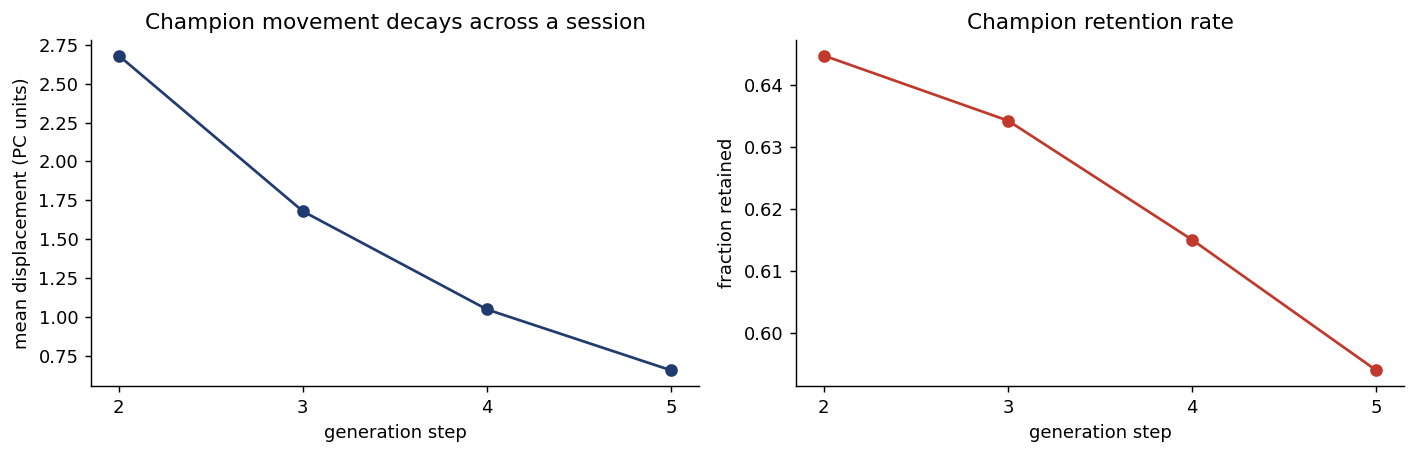

In [5]:
coords = wide.drop_duplicates("vase_id").set_index("vase_id")[PC_COLUMNS]
p = coords.reindex(edges.parent_vase_id).to_numpy()
c = coords.reindex(edges.child_vase_id).to_numpy()
step = np.linalg.norm(c - p, axis=1)

conv = (pd.DataFrame({"generation": edges.generation_num, "displacement": step,
                      "stayed": step < 1e-12})
        .groupby("generation")
        .agg(mean_displacement=("displacement", "mean"),
             stay_rate=("stayed", "mean"),
             n=("displacement", "size")))
display(conv.round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), dpi=130)
ax[0].plot(conv.index, conv.mean_displacement, "o-", color="#1f3b70")
ax[0].set_xlabel("generation step"); ax[0].set_ylabel("mean displacement (PC units)")
ax[0].set_title("Champion movement decays across a session")
ax[1].plot(conv.index, conv.stay_rate, "o-", color="#c0392b")
ax[1].set_xlabel("generation step"); ax[1].set_ylabel("fraction retained")
ax[1].set_title("Champion retention rate")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)
    a.set_xticks(conv.index)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "convergence.png"), dpi=200); plt.show()

## 5. How a single plane is fitted

For one PC pair, `run_pc_pair` does the following:

1. **Project** every vase onto that plane. (`pair_frame` exposes the pair under the column names
   `umap_x`/`umap_y`, which is simply `koopman_gravity`'s generic coordinate slot — no UMAP is
   involved.)
2. **Bound** the plane at the 0.5th–99.5th percentiles. PC scores have long tails — PC1 runs from
   −21.6 to 27.7 with a standard deviation of 5.7 — so using the extremes would spend most of the
   grid on a few outliers.
3. **Lift** the coordinates into a 15×15 grid of Gaussian RBFs (225 basis functions) and estimate
   the Koopman operator `K` by ridge-regularised least squares. The ridge is essential: without
   it the RBF Gram matrix is near-singular and the fitted spectrum is meaningless. PC planes need
   `ridge=1e-3`, slightly more than UMAP space needed.
4. **Take mode 1**, the slowest non-trivial eigenfunction. Mode 0 has eigenvalue ≈ 1, is conserved
   along the dynamics and single-signed, so it describes where vases accumulate rather than any
   direction of travel.
5. **Orient** the eigenfunction's sign — which is mathematically arbitrary — so that the
   higher-Φ vase is the one people actually chose, judged across all 68,100 matchups.

`spectral_radius` is the sanity check. A Koopman operator's spectrum belongs inside the unit
disk; a value much above 1 means the fit is numerically unsound.

In [6]:
demo = run_pc_pair(wide, edges, matchups, "PC1", "PC2")
print(f"PC1 vs PC2")
print(f"   eigenvalue (mode 1) : {demo['eigenvalue'].real:.4f}")
print(f"   spectral radius     : {demo['spectral_radius']:.4f}   (must be <= ~1)")
print(f"   matchup win rate    : {demo['win_rate']:.4f}   over {demo['n_matchups']:,} comparisons")
print(f"   plane bounds        : x {demo['bounds']['x_min']:.2f}..{demo['bounds']['x_max']:.2f}"
      f"   y {demo['bounds']['y_min']:.2f}..{demo['bounds']['y_max']:.2f}")

PC1 vs PC2
   eigenvalue (mode 1) : 0.9639
   spectral radius     : 0.9834   (must be <= ~1)
   matchup win rate    : 0.5469   over 68,100 comparisons
   plane bounds        : x -13.80..13.19   y -14.06..8.08


## 6. Fit every PC plane

Fifteen pairs for six PCs. The table is sorted by **matchup win rate**, which is the useful
quantity: it says how much a plane's coordinates tell you about which vase a person picked.
0.5 is chance.

### Table 2 — every PC plane

Sorted by matchup win rate: how much a plane's coordinates tell you about which vase a person
picked. 0.5 is chance. `spectral_radius` is the numerical sanity check — a Koopman spectrum
belongs inside the unit disk.

In [7]:
results = run_all_pc_pairs(wide, edges, matchups, verbose=False)
summary = pair_summary(results)
summary.style.background_gradient(subset=["win_rate"], cmap="Blues").format({
    "eigenvalue": "{:.4f}", "spectral_radius": "{:.4f}", "win_rate": "{:.4f}"})

,pc_x,pc_y,eigenvalue,spectral_radius,win_rate,n_matchups
0,PC1,PC2,0.9639,0.9834,0.5469,68100
1,PC3,PC4,0.9645,0.9952,0.5462,68100
2,PC1,PC3,0.9621,0.9908,0.5378,68100
3,PC1,PC6,0.9605,0.9869,0.5341,68100
4,PC3,PC5,0.9712,0.9945,0.5325,68100
5,PC1,PC4,0.9602,0.9890,0.5319,68100
6,PC2,PC3,0.9701,0.9924,0.5307,68100
7,PC5,PC6,0.9692,0.9936,0.5269,68100
8,PC2,PC5,0.9692,0.9900,0.5250,68100
9,PC1,PC5,0.9646,0.9876,0.5202,68100


In [8]:
assert summary.spectral_radius.max() < 1.05, "a plane produced a non-physical spectrum"
print(f"all {len(summary)} planes fitted; max spectral radius {summary.spectral_radius.max():.4f}")

all 15 planes fitted; max spectral radius 0.9952


## 6b. Figure 2 — one-dimensional drift along each PC

The cleanest summary of "how people move through PC space" needs **one panel per PC, not one per
pair**. For each PC this plots the mean displacement along that axis against the current position
on it.

**What the points are.** Each dot is a bin of champion transitions: all 54,480 transitions are
sorted by their position on that PC and split into 25 quantile bins of roughly 2,200 each. The
dot sits at (mean position in the bin, mean displacement over the next generation), and the error
bar is one standard error of that mean. Retentions are included, so a bin sitting at zero means
champions there tend not to move at all.

**Why the fit is a spline.** Selection is neither a straight line nor a symmetric curve. PC1
inverts at the bottom *and* flattens at the top, which a parabola cannot represent, and PC3 rises
before it falls. The fit is therefore a penalised cubic B-spline — a GAM with one smooth term —
with the number of knots chosen by cross-validation grouped on participant, so flexibility is set
by how well the curve predicts people it has not seen. Selection uses the one-standard-error rule
rather than the outright best score, which returns the simplest curve the data cannot distinguish
from the best one; here that is 4 knots for every PC, so the data supports real curvature but not
wiggle.

Against the binned means the spline clearly improves on both simpler fits:

| | linear | quadratic | spline |
|---|---|---|---|
| PC1 | 0.74 | 0.90 | **0.96** |
| PC3 | 0.85 | 0.89 | **0.95** |
| PC5 | 0.87 | 0.90 | **0.95** |

(Against raw single transitions every R² is ~0.01, because 62% of transitions are
zero-displacement retentions and individual steps are dominated by noise. The binned comparison
is the one that answers "does the curve track the trend".)

**What to read off each panel.**

- **The restoring slope** — the gradient of the drift curve at the fixed point. Negative means
  the dynamics restore: champions above the fixed point move down, those below move up.
- **The fixed point** — the dotted line, where drift crosses zero downwards, i.e. the value that
  axis pulls towards. Read it with its percentile among the champion positions actually visited:
  near the 50th is a genuine interior optimum, near the 1st is pinned against the edge of the
  design space the generator could produce.

A flexible curve is free to cross zero several times and so to report several attractors, plus
unstable roots where the dynamics push away rather than pull in. That freedom is the point of
using it — and it finds exactly **one stable fixed point per PC and no unstable ones**, each
within ~0.3 of the quadratic estimate. The single-attractor result therefore holds across linear,
quadratic and spline fits rather than being an artefact of assuming a simple shape.

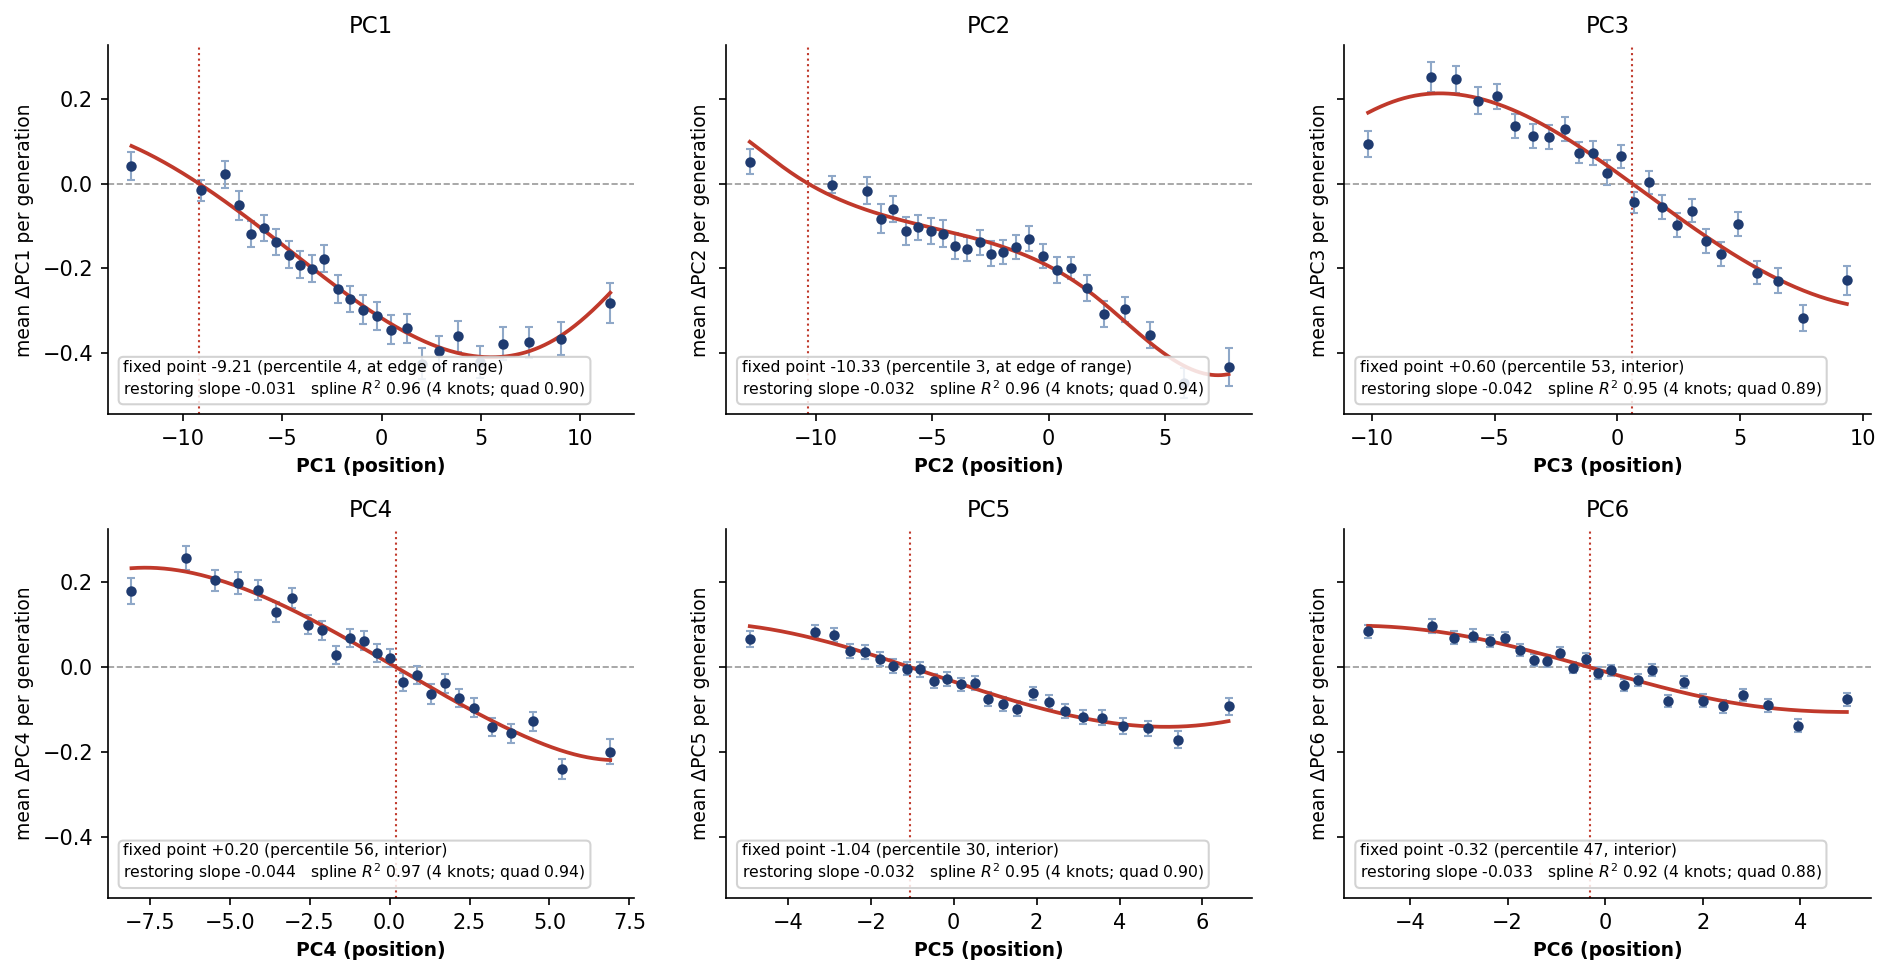

In [9]:
drift_1d = per_pc_drift(edges, wide)
plot_per_pc_drift(drift_1d, save_path=os.path.join(FIG_DIR, "fig2_per_pc_drift.png"))

Every PC is restoring (slopes −0.031 to −0.044), but they split into two classes:

- **PC3, PC4, PC6** have fixed points near the middle of the visited range (+0.60, +0.20, −0.32;
  percentiles 53, 56, 47) and close to where generation-5 champions actually end up. These axes
  have settled on an interior optimum. PC5 sits just below the middle (−1.04, percentile 30).
- **PC1 and PC2** have fixed points at the 4th and 3rd percentile (−9.21 and −10.33) — against
  the edge of the design space rather than inside it. On these axes participants were still
  pushing outwards when the session ended, which is consistent with PC1 being the single most
  predictive axis of choice (60.2%).

The shapes differ too. PC1's drift is strongly negative through the middle of the range but
flattens and turns back up beyond PC1 ≈ 5, so the pull towards low PC1 weakens once a champion is
already extreme — there is less design space left to move into. That asymmetry is exactly what
the spline captures and the parabola could not.

### Table 1 — what each PC carries

Per-PC companion to Figure 2: how often the vase with the higher value of that PC wins, its
weight in the six-PC Bradley–Terry model, the stable fixed point of its drift with the local
restoring slope there, and the best plane that PC appears in.

In [10]:
table1 = pc_signal_table(results, wide, matchups, drift_1d)
table1.style.background_gradient(subset=["win_rate_alone"], cmap="Blues").format({
    "win_rate_alone": "{:.4f}", "bt_weight": "{:+.4f}", "drift_slope": "{:+.4f}",
    "fixed_point": "{:+.2f}", "fixed_point_pct": "{:.1f}", "best_plane_win_rate": "{:.4f}"})

,PC,win_rate_alone,bt_weight,restoring_slope,fixed_point,fixed_point_pct,interior,best_plane,best_plane_win_rate
0,PC1,0.6018,-0.1382,-0.030751,-9.21,3.7,False,PC1 vs PC2,0.5469
1,PC2,0.5129,+0.0290,-0.032264,-10.33,2.6,False,PC1 vs PC2,0.5469
2,PC3,0.5353,+0.0495,-0.042208,+0.60,53.5,True,PC3 vs PC4,0.5462
3,PC4,0.5390,+0.0869,-0.044033,+0.20,56.0,True,PC3 vs PC4,0.5462
4,PC5,0.5310,-0.1074,-0.032401,-1.04,30.3,True,PC3 vs PC5,0.5325
5,PC6,0.5175,+0.0578,-0.032701,-0.32,47.1,True,PC1 vs PC6,0.5341


## 7. The gravity fields for all 15 PC planes

Every pair on one sheet, ordered by descending matchup win rate. Colour is the gravity potential
Φ: high values are the shapes people preferred, because that is how the sign was fixed.

The magenta streamlines trace **the gradient of the fitted potential** — which way Φ rises and
how steeply, in relative units. They are *not* measured movement, and their thickness carries no
per-generation scale. Section 8 shows the measured flow instead.

Note these are 15 *marginals of one six-dimensional process*: each panel shows two axes and
averages over the other four, and the lowest-scoring planes sit close to chance. Read them for
the shape of the flow rather than as independent results.

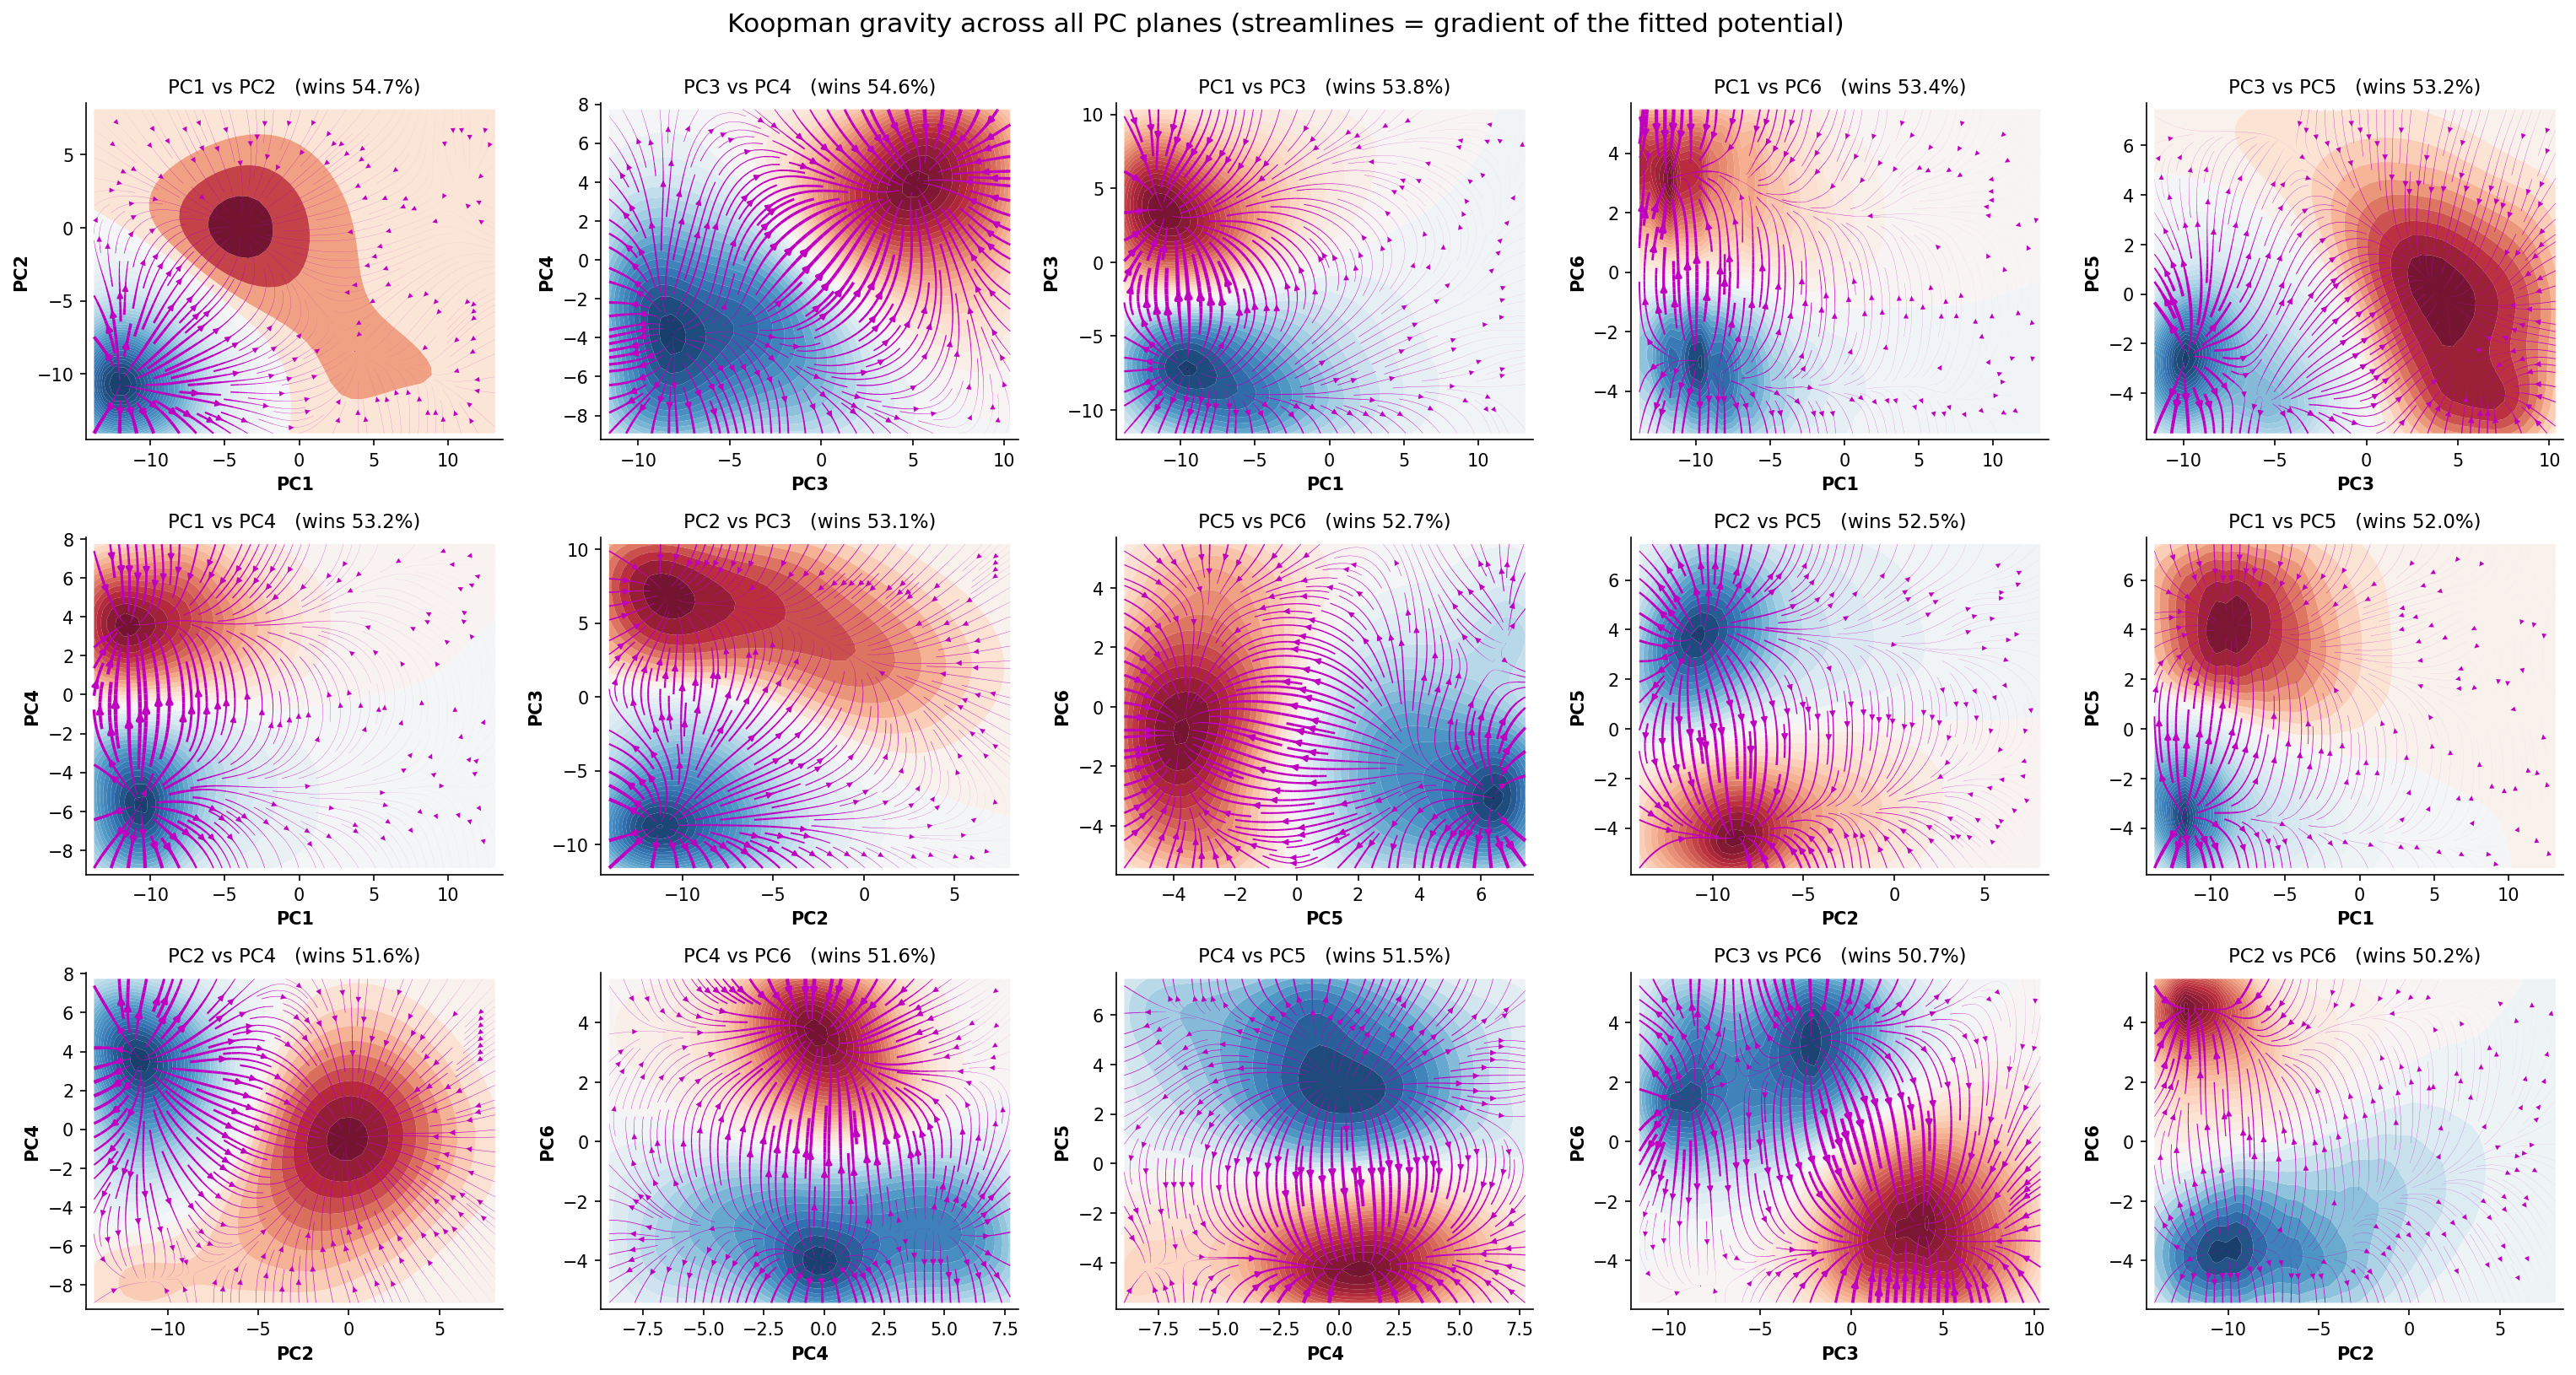

In [11]:
plot_pc_pair_grid(results, n_cols=5,
                  save_path=os.path.join(FIG_DIR, "pc_gravity_fields_all_pairs.png"),
                  suptitle="Koopman gravity across all PC planes "
                           "(streamlines = gradient of the fitted potential)")

## 8. Figure 3 — measured flow in the two strongest planes

The corner plot is dense by design. For the main text, the two highest-scoring planes are shown
at full size, because this is the honest "how do people move" picture: for each cell, the **mean
observed displacement** of the champion transitions starting there.

Arrow direction is where participants went; arrow length is how far, **in PC units per
generation** — a real scale rather than a normalised one. Retentions are included, so a short
arrow genuinely means "people tend to stay here".

Cells with fewer than 25 transitions are dropped. Sparse cells at the edge of the occupied
region show spurious inward flow simply because all their populated neighbours lie inward, and
that artefact is easy to mistake for an attractor.

Each panel is validated by **split-half reproducibility**: participants are split into two
disjoint halves, the drift field computed separately on each, and the two correlated.
Participants rather than transitions, because transitions within a session share champions along
one chain and would leak.

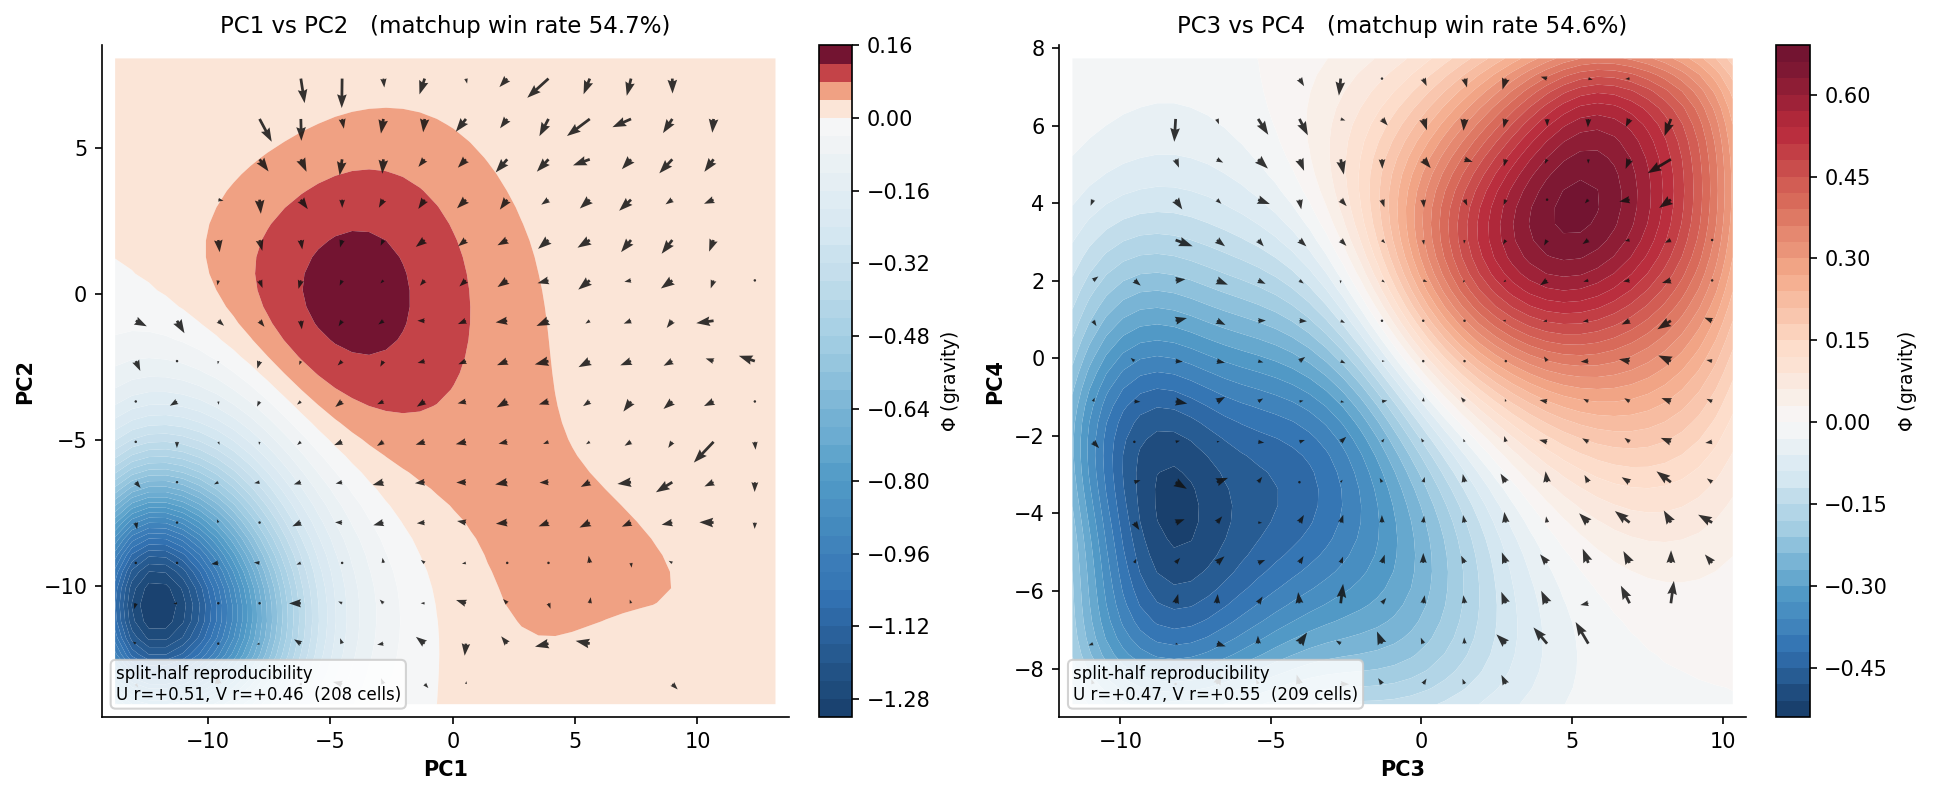

In [12]:
main_planes = [(r.pc_x, r.pc_y) for _, r in summary.head(2).iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), dpi=150)
for ax, key in zip(np.atleast_1d(axes), main_planes):
    res   = results[key]
    frame = pair_frame(wide, *key)
    drift = drift_on_plane(edges, frame, res["bounds"], n_grid=16, min_count=25)
    rU, rV, n_cells = drift_split_half(edges, frame, res["bounds"], n_grid=16, min_count=12)
    _, cf = plot_pc_pair(res, drift=drift, ax=ax,
                         title=f"{key[0]} vs {key[1]}   (matchup win rate {res['win_rate']:.1%})")
    ax.annotate(f"split-half reproducibility\nU r={rU:+.2f}, V r={rV:+.2f}  ({n_cells} cells)",
                xy=(0.02, 0.02), xycoords="axes fraction", fontsize=8, va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.85))
    fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04).set_label(r"$\Phi$ (gravity)", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig3_measured_drift_main_planes.png"), dpi=200,
            bbox_inches="tight")
plt.show()

## 9. How much preference does each plane actually carry?

The Koopman field describes **dynamics** — the slow directions of the selection process. It is
not fitted to predict choice; the matchup data only fixes its sign. So it is worth asking
separately how much preference information the PC coordinates hold, as a benchmark for what any
map of these planes could show.

Three references below:

- **each PC on its own** — how often the vase with the higher value of that PC wins;
- **a Bradley–Terry model on all six PCs**, which is the linear ceiling;
- **the same with quadratic terms**, which allows preference to peak at an *interior* value
  rather than increasing without bound.

In [13]:
from sklearn.linear_model import LogisticRegression

pc = wide.drop_duplicates("vase_id").set_index("vase_id")[PC_COLUMNS]
W  = pc.reindex(matchups.winner_vase_id).to_numpy()
L  = pc.reindex(matchups.loser_vase_id).to_numpy()

single = pd.DataFrame({
    "PC": PC_COLUMNS,
    "win_rate_alone": [max((W[:, i] > L[:, i]).mean(), (W[:, i] < L[:, i]).mean())
                       for i in range(len(PC_COLUMNS))],
})

X = np.vstack([W - L, L - W])                       # symmetric design, no intercept
y = np.r_[np.ones(len(W)), np.zeros(len(W))]
linear = LogisticRegression(fit_intercept=False).fit(X, y)

Xq = np.hstack([X, np.vstack([W**2 - L**2, L**2 - W**2])])
quad = LogisticRegression(fit_intercept=False, max_iter=2000).fit(Xq, y)

single["bt_weight"] = linear.coef_[0]
display(single.sort_values("win_rate_alone", ascending=False).round(4))

print(f"best single PC plane (Koopman field) : {summary.win_rate.max():.4f}")
print(f"Bradley-Terry, 6 PCs, linear         : {linear.score(X, y):.4f}")
print(f"Bradley-Terry, 6 PCs, + quadratic    : {quad.score(Xq, y):.4f}")

,PC,win_rate_alone,bt_weight
0,PC1,0.6018,-0.1382
3,PC4,0.5390,0.0869
2,PC3,0.5353,0.0495
4,PC5,0.5310,-0.1074
5,PC6,0.5175,0.0578
1,PC2,0.5129,0.0290


best single PC plane (Koopman field) : 0.5469
Bradley-Terry, 6 PCs, linear         : 0.6195
Bradley-Terry, 6 PCs, + quadratic    : 0.6336


## 10. What the numbers say

**PC space carries more preference signal than the UMAP embedding.** A linear model on all six
PCs predicts 62.0% of head-to-head choices, rising to 63.4% once quadratic terms allow an
interior optimum. The UMAP Koopman field reached 59.6%. Working in the experiment's own
coordinates loses nothing and gains interpretability.

**Most of that signal is in PC1**, which alone calls 60.2% of matchups. The remaining PCs
contribute little individually, though the full model beats PC1 alone, so they are not redundant.

**All six axes show restoring dynamics** (restoring slopes −0.031 to −0.044), which is the
sharpest single statement that there is an aesthetic attractor: wherever a champion sits, the
next generation pulls it back towards a fixed value. Four of the six fixed points are interior;
PC1 and PC2's sit at the edge of the design space, so on those axes the process had not finished
within five generations.

**One attractor per axis, robustly.** The spline is free to report several fixed points and
finds one on every PC, agreeing with the quadratic to within ~0.3. So the single-attractor
conclusion is a property of the data rather than of the fit family.

**No 2D plane can show the whole story.** The best Koopman plane reaches a win rate well below
the 6-PC ceiling, because each plane is a marginal view of a six-dimensional process — two axes
shown, four averaged over. Plane maps are worth reading for the *shape of the flow*, not as a
complete account of preference.

**The Koopman field and the preference ranking are different objects.** The field is the slow
mode of the dynamics; the matchup data only orients it. A plane can carry real preference
information in its coordinates while its slow mode aligns poorly with that preference, and the
gap between a plane's win rate and its PCs' individual win rates is exactly that discrepancy.

**Preference peaks at an interior point, it does not rise without bound.** Both the quadratic
Bradley–Terry model beating the linear one and the interior fixed points in Figure 2 say the
same thing: there is a sweet spot in PC space, and the convergence in section 4 is the process
moving towards it.

## 11. Seeing the shapes: synthesising vases from PC values

Everything so far has been maps of coordinates. But the PCs are the parameters the generator
actually used, so a PC value can be turned back into a vase: the PCA was fitted on profiles
encoded as `[x₁..x₂₅₀, y₁..y₂₅₀]`, and the inverse transform is `X = scores @ components + mean`.

Checked against a stored profile, six components reproduce the outline to an RMSE of 0.031 on an
x-range of 3.0 — about 1%, easily good enough to draw.

The vases in the next two figures are coloured by the **Koopman gravity field Φ**, the same
quantity the contour maps in sections 7 and 8 show. For the plane figure that is each plane's own
2-D field; for the 1-D scan it is a field fitted along that single PC (section 12). Because an
eigenvector carries an arbitrary norm, each field is expressed in standard deviations of itself
across the real champion positions so that the panels share a colour scale.

PCA basis: 6 components x 500 features (250 contour points)


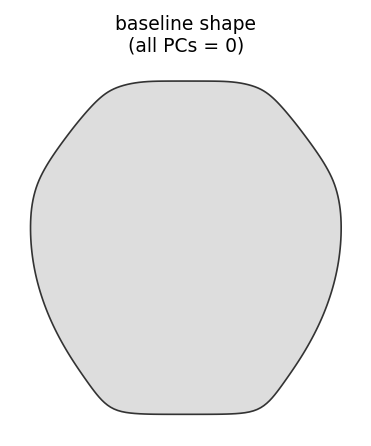

In [14]:
components, pca_mean, n_points = load_pca_basis()

print(f"PCA basis: {components.shape[0]} components x {components.shape[1]} features "
      f"({n_points} contour points)")

# Sanity check: the baseline shape is the corpus mean, i.e. all PCs at zero.
bx, by = synthesise_vase(np.zeros(6), components, pca_mean)
fig, ax = plt.subplots(figsize=(2.6, 3.0), dpi=150)
ax.fill(bx, by, facecolor="#dddddd", edgecolor="#333333", linewidth=0.8)
ax.set_aspect("equal"); ax.axis("off"); ax.set_title("baseline shape\n(all PCs = 0)", fontsize=9)
plt.tight_layout(); plt.show()

## 12. Figure 4 — a scan along each PC on its own

One row per PC. Along each row only that component changes; the other five are held at the
baseline, so **every shape difference in a row is caused by that single PC**. The scan spans the
2nd to 98th percentile of the champion positions actually visited, so it stays inside the design
space participants explored.

Colour is that PC's **one-dimensional Koopman gravity field**, red where gravity is high and blue
where it is low. This needs its own fit: the plane fits in section 6 are 2-D, and reading a line
out of one would make the answer depend on which partner PC happened to be chosen. `run_pc_axis`
therefore fits the operator with the champion's position on a single PC as the state, reusing the
same RBF lifting, ridge and mode selection with the second coordinate pinned to zero.

As everywhere else, the sign of the eigenfunction — which is mathematically arbitrary — is fixed
so the higher-Φ vase is the one people chose. That is the only role the matchups play; the values
themselves are the Koopman field.

  PC1: lambda = 0.9524   radius = 0.9894   win rate = 0.5115


  PC2: lambda = 0.9614   radius = 0.9920   win rate = 0.5174
  PC3: lambda = 0.9567   radius = 0.9964   win rate = 0.5356


  PC4: lambda = 0.9497   radius = 0.9968   win rate = 0.5314


  PC5: lambda = 0.9603   radius = 0.9952   win rate = 0.5141


  PC6: lambda = 0.9578   radius = 0.9958   win rate = 0.5140


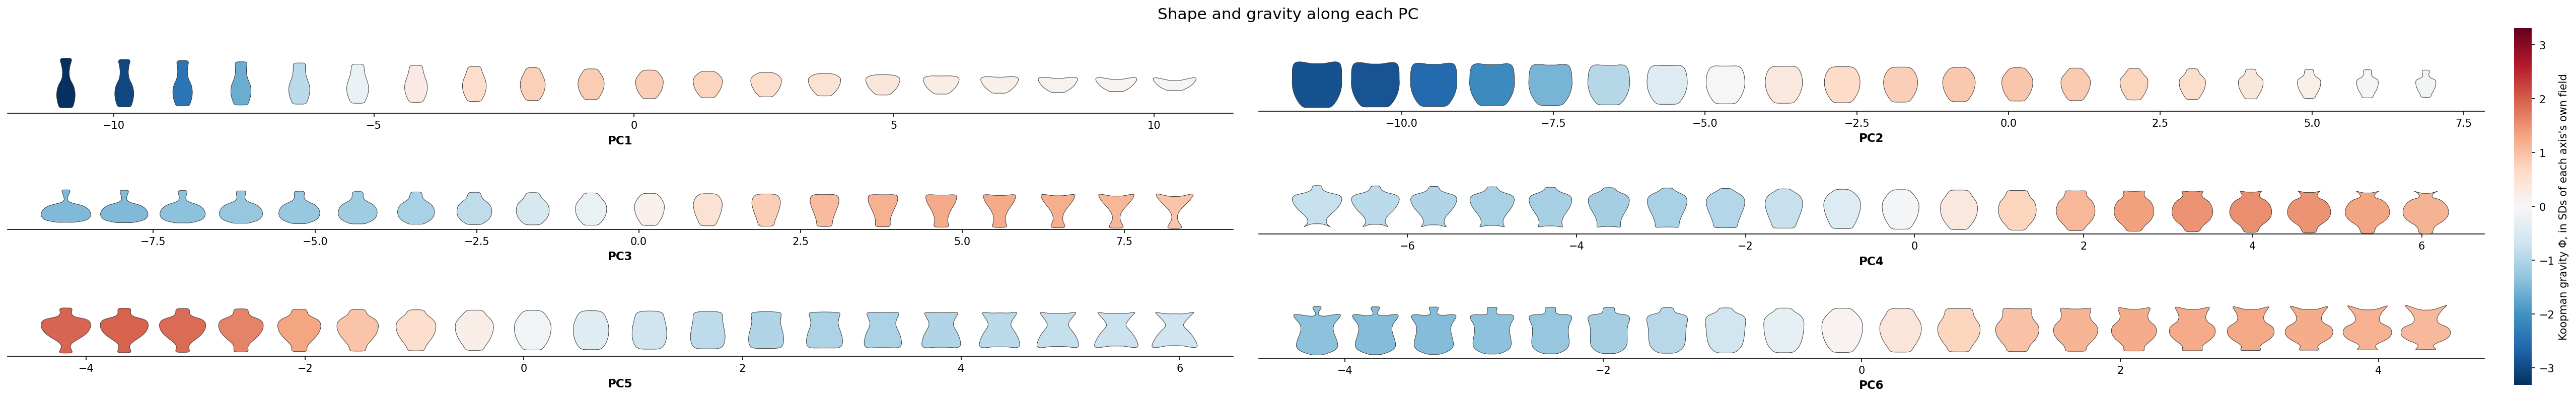

In [15]:
axis_fields = run_all_pc_axes(wide, edges, matchups)

plot_pc_1d_vase_scan(wide, axis_fields, components, pca_mean,
                     save_path=os.path.join(FIG_DIR, "fig4_pc_1d_vase_scan.png"), n_show=20)

## 13. Figure 5 — vase shape across every PC plane

The same idea in two dimensions, for all 15 pairs. At each lattice point the two PCs of that
plane are set to the position and the other four are held at the baseline, so the shape variation
within a panel is caused by those two components alone.

This is the companion to the gravity-field sheet in section 7: that one draws Φ as contours, this
one draws the pots that Φ is defined over, coloured by the same field — evaluated exactly from
each plane's eigenfunction rather than interpolated from the plotted grid. Panels are ordered by
matchup win rate.

Colour is normalised once across all 15 panels, after each plane's Φ has been put into units of
its own spread, so a red vase in one panel means the same as a red vase in another. The scale is
clipped at the 95th percentile of absolute Φ, because the far corners of the wider planes are
combinations almost nobody visited and would otherwise flatten every panel.

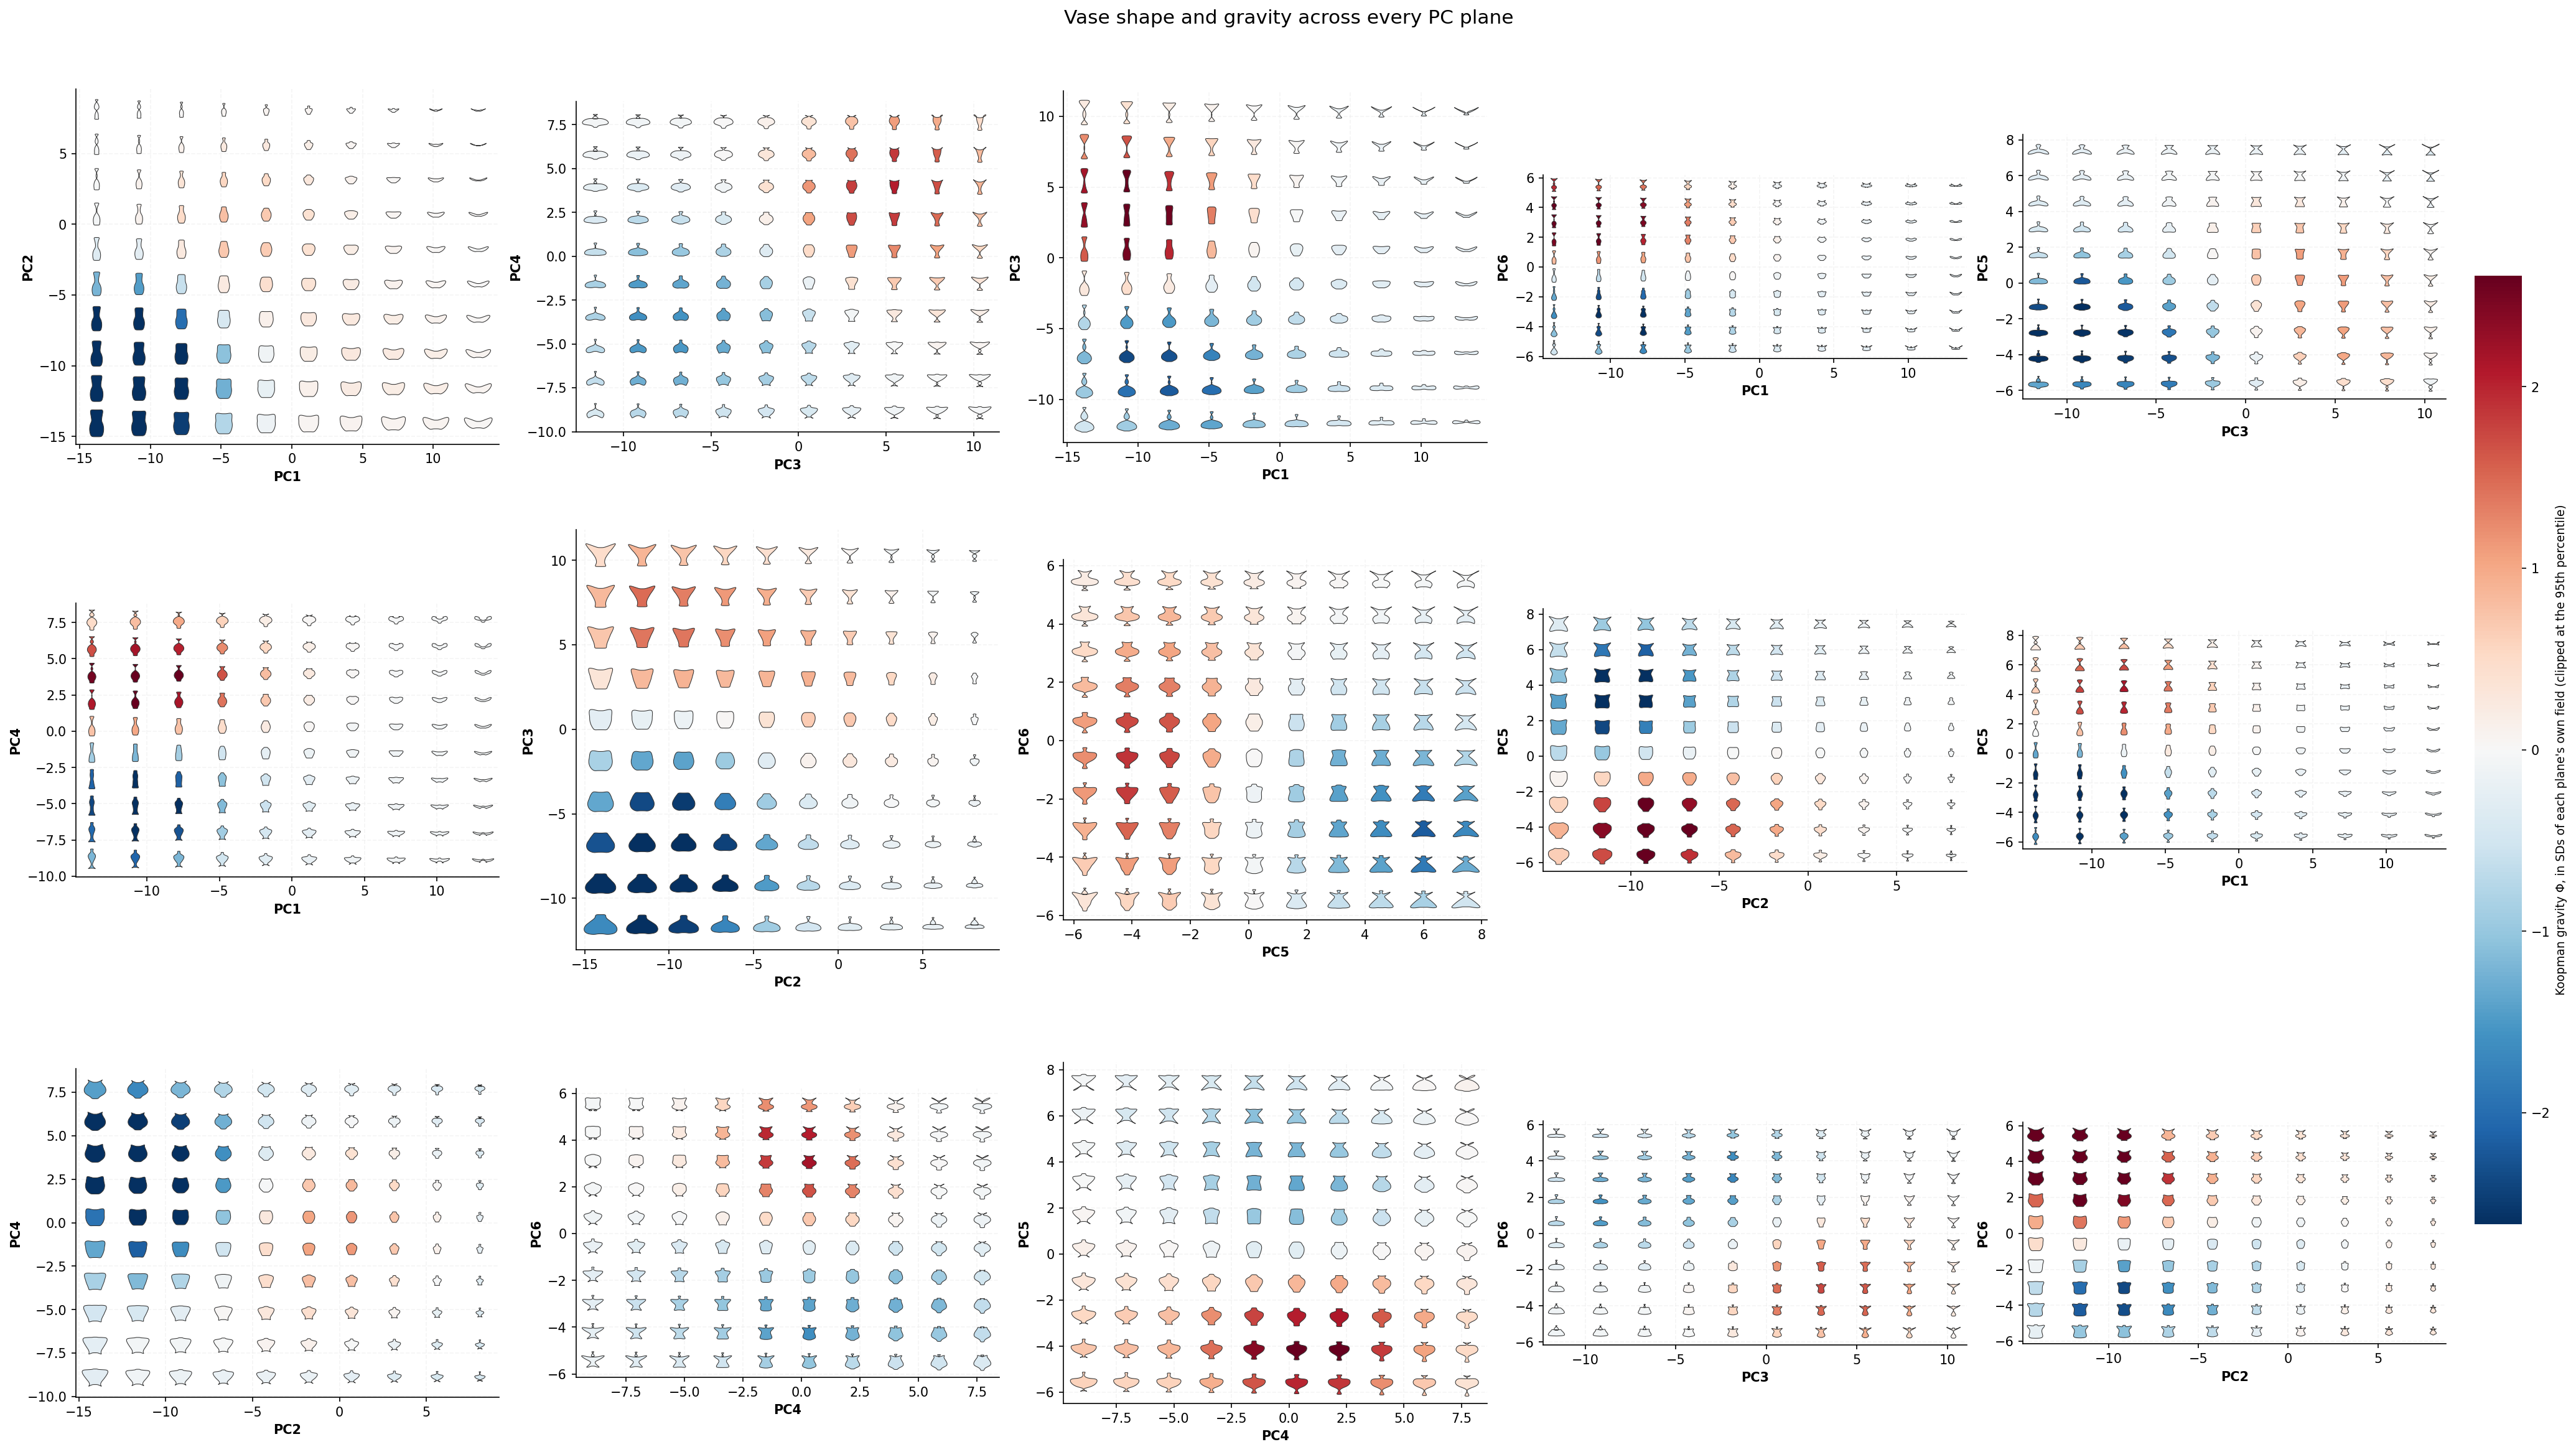

In [16]:
plot_pc_pair_vase_grid(results, wide, components, pca_mean, n_show=10,
                       save_path=os.path.join(FIG_DIR, "fig5_pc_plane_vase_grid.png"))

**Gravity is not the same as preference, and PC1 shows it most sharply.**

Colouring by Φ answers "where does the selection process dwell and flow", which is a different
question from "which vase wins a comparison". Comparing the 1-D field against the head-to-head
model along each scan:

| PC | correlation | 1-D field win rate |
|---|---|---|
| **PC1** | **−0.55** | 0.512 |
| PC2 | +0.97 | 0.517 |
| PC3 | +0.85 | 0.536 |
| PC4 | +0.87 | 0.531 |
| PC5 | +0.69 | 0.514 |
| PC6 | +0.79 | 0.514 |

Five of six agree. **PC1 actively disagrees** — and it is the axis carrying the most preference
signal (60.2% on its own). Its gravity field peaks in the middle of the range while preference
rises monotonically towards low PC1, and the field's own win rate is 0.512, barely above chance.
So on PC1 the colours in Figures 4 and 5 should be read as "where champions accumulate", not as
"what people found beautiful" — those point in opposite directions.

That is consistent with what section 10 says about the two objects being different, and with the
1-D fields having much weaker win rates (0.512–0.536) than the raw PC values do. If the question
is which shapes people preferred, the head-to-head model is the right scorer; if it is where the
evolutionary process settles, this is.

## 14. Table 3 — how strong is selection on each PC?

The colour in Figures 4 and 5 is the gravity field, which is a *dynamical* quantity. It is not a
measure of how hard people selected on a component, and on some axes it is close to chance. This
table measures selection directly, and separates it from what the generator happened to offer.

Everything is in standard deviations of that PC among the vases on offer, so components with
different spreads are comparable.

- **`selection_i`** — the standardised selection differential, the classical intensity of
  selection. Each matchup offers two vases and one is kept, so that matchup's differential is
  (winner − loser) / 2: how far the kept vase sits from the mean of what was available. This is
  the honest answer to "how strongly did people select on this component".
- **`generator_bias`** — the mean (challenger − incumbent) across offers. The challenger is drawn
  by the generator, not chosen by anyone, so a systematic offset here moves the champion
  population regardless of preference.
- **`realised_change`** — the actual shift in the champion population from generation 1 to
  generation 5. It is the *sum* of the two effects, and must not be read as selection.

Intervals are bootstrapped over participants, since each contributes 25 correlated comparisons.

In [17]:
selection = selection_strength(wide, matchups)
selection.style.background_gradient(subset=["selection_i"], cmap="RdBu_r").format({
    "sd": "{:.2f}", "selection_i": "{:+.4f}", "ci_lo": "{:+.4f}", "ci_hi": "{:+.4f}",
    "generator_bias": "{:+.4f}", "realised_change": "{:+.4f}"})

,PC,sd,selection_i,ci_lo,ci_hi,generator_bias,realised_change,selection_dominates
0,PC1,5.72,-0.0888,-0.0918,-0.0859,+0.0125,-0.1692,True
1,PC4,3.53,+0.0388,+0.0358,+0.0418,-0.0284,+0.0258,True
2,PC3,4.70,+0.0373,+0.0341,+0.0404,-0.0321,+0.0051,True
3,PC5,2.75,-0.0341,-0.0369,-0.0313,-0.0059,-0.0663,True
4,PC6,2.30,+0.0158,+0.0126,+0.0189,-0.0283,-0.0127,False
5,PC2,4.56,+0.0080,+0.0051,+0.0109,-0.1100,-0.1497,False


**PC1 is by far the most strongly selected component** — a differential of −0.089 SD per
generation, 2.3× the next largest, and its generator bias is +0.013, i.e. negligible and pointing
the *other* way. Its movement is genuinely chosen. PC4, PC3 and PC5 follow at roughly 0.034–0.039,
each also selection-dominated.

**PC2 is not selected at all.** Its differential is +0.008 SD — statistically distinguishable from
zero only because n = 68,100, and *positive* while its population moved negative. The champion pool
slides to low PC2 because the generator offers challengers 0.110 SD below the incumbent (−0.307 SD
at generation 2 alone). Anyone reading the drift maps for PC2 would conclude "people move towards
low PC2"; the correct statement is "the generator keeps offering lower PC2, and participants are
indifferent".

This is the important caveat for the flow figures generally: a drift field measures where the
population went, which is selection **plus** whatever the generator supplied. Only `selection_i`
isolates the part attributable to human choice. PC6 is the other axis where the generator
outweighs selection.

Note also that this reorders the components against the apparent strength in Figure 5. That figure
is coloured by Φ, whose agreement with choice is weakest precisely on PC1 (1-D field win rate
0.512) — so the axis with the strongest selection looks the least dramatic there.